# 04. PyTorch custom Datasets

Get your own datasets

## Domain libraries

Check in which categories belongs your data : torchvision, torchaudio...

## Ajout des images dans le bon fichier


## 7. Model 0: TinyVGG  without data augmentation

Let's replicaite the TinyVGG architecture from the CNN Explainer

### 7.1 Creating transforms and loading data for Model 0


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [ ]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                      transform=simple_transform,
                                      target_transform=None)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                      transform=simple_transform,
                                      target_transform=None)

# 2. Turn the datasets into DataLoader
import os
from torch.utils.data import DataLoader

# Setup batch size and number of works
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()


train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                      batch_size=BATCH_SIZE,
                                      num_workers=NUM_WORKERS,
                                      shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                      batch_size=BATCH_SIZE,
                                      num_workers=NUM_WORKERS,
                                      shuffle=False)



### 7.2 Create TinyVGG model class

In [ ]:
from torch import nn
class TinyVGG(nn.Module):
  """Creates the TinyVGG architecture.

  Replicates the TinyVGG architecture from the CNN explainer"""

  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(nn.Conv2d(in_channels=input_shape,
                                                out_channels = hidden_units,
                                                kernel_size=3,
                                                stride = 1,
                                                padding =0
                                                ),
                                      nn.ReLU(),
                                      nn.Conv2d(in_channels = hidden_units,
                                                out_channels = hidden_units,
                                                kernel_size = 3,
                                                stride = 1,
                                                padding = 0),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2,
                                                   stride=2) # default stride value is same as kernel_size
                                      )
    self.conv_block_2 = nn.Sequential(nn.Conv2d(in_channels=hidden_units,
                                                out_channels = hidden_units,
                                                kernel_size=3,
                                                stride = 1,
                                                padding =0
                                                ),
                                      nn.ReLU(),
                                      nn.Conv2d(in_channels = hidden_units,
                                                out_channels = hidden_units,
                                                kernel_size = 3,
                                                stride = 1,
                                                padding = 0),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2,
                                                   stride=2)
                                      )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x # or we can use fusion, benefits from operator fusion (f(y(x)))


In [ ]:

model_0 = TinyVGG(input_shape=3,
                  hidden_units = 10,
                  output_shape=len(train_data_simple.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### 7.3 Try a forward pass on a simple image (to test the model)

In [ ]:
# get a single image
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
# Try a forward pass
model_0(image_batch.to(device))

tensor([[0.0336, 0.0539, 0.0143],
        [0.0388, 0.0523, 0.0086],
        [0.0421, 0.0550, 0.0002],
        [0.0348, 0.0561, 0.0023],
        [0.0299, 0.0581, 0.0135],
        [0.0344, 0.0577, 0.0116],
        [0.0375, 0.0554, 0.0124],
        [0.0364, 0.0570, 0.0134],
        [0.0263, 0.0511, 0.0100],
        [0.0368, 0.0539, 0.0026],
        [0.0357, 0.0594, 0.0092],
        [0.0333, 0.0557, 0.0132],
        [0.0396, 0.0562, 0.0117],
        [0.0336, 0.0532, 0.0048],
        [0.0332, 0.0540, 0.0104],
        [0.0309, 0.0547, 0.0142],
        [0.0305, 0.0569, 0.0058],
        [0.0381, 0.0588, 0.0172],
        [0.0413, 0.0509, 0.0081],
        [0.0367, 0.0512, 0.0138],
        [0.0182, 0.0575, 0.0118],
        [0.0370, 0.0630, 0.0152],
        [0.0250, 0.0583, 0.0129],
        [0.0294, 0.0514, 0.0108],
        [0.0280, 0.0575, 0.0149],
        [0.0288, 0.0525, 0.0124],
        [0.0386, 0.0581, 0.0139],
        [0.0327, 0.0543, 0.0122],
        [0.0435, 0.0546, 0.0150],
        [0.022

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model

## 9. Model 1: TinyVGG with data augmentation

Same model but some data augmentation

### 9.1 Create transform with data augmentation

In [ ]:
# Create training transform with TrivialAugment
from torchvision import transforms

train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(224,224)),
    #transforms.TrivialAugmentWide(num_magnitude_bins =31),
    transforms.ToTensor()
])

# Create testing transform
test_transform_simple = transforms.Compose([transforms.Resize(size=(64,64)),
                                            transforms.ToTensor()])



### 9.2 Create train and `dataset`'s and `DataLoader`'s with data augmentation

In [ ]:
# Turn image folders into Datasets
from torchvision import datasets

train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform=train_transform_trivial,
                                            )

test_data_simple = datasets.ImageFolder(root=test_dir,
                                            transform=test_transform_simple,
                                            )

In [ ]:
# Turn our Datasets into DataLoader
import os
import torch
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 12
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)


### 9.3 Construct and train model 1


In [ ]:
# Create model_1 and send it to the target device

model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)
).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:

# Set the number of epochs
NUM_EPOCHS = 5

# Setup loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                         lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model 1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.1084 | Train acc: 0.3085 | Test loss: 1.1110 | Test acc: 0.2738
Epoch: 1 | Train loss: 1.0967 | Train acc: 0.3406 | Test loss: 1.1057 | Test acc: 0.2976
Epoch: 2 | Train loss: 1.0928 | Train acc: 0.3611 | Test loss: 1.1097 | Test acc: 0.2976
Epoch: 3 | Train loss: 1.0672 | Train acc: 0.4591 | Test loss: 1.0571 | Test acc: 0.3929
Epoch: 4 | Train loss: 1.0103 | Train acc: 0.4912 | Test loss: 0.9995 | Test acc: 0.4048
Total training time: 17.553 seconds


### 9.4 Plot the loss curves of model_1

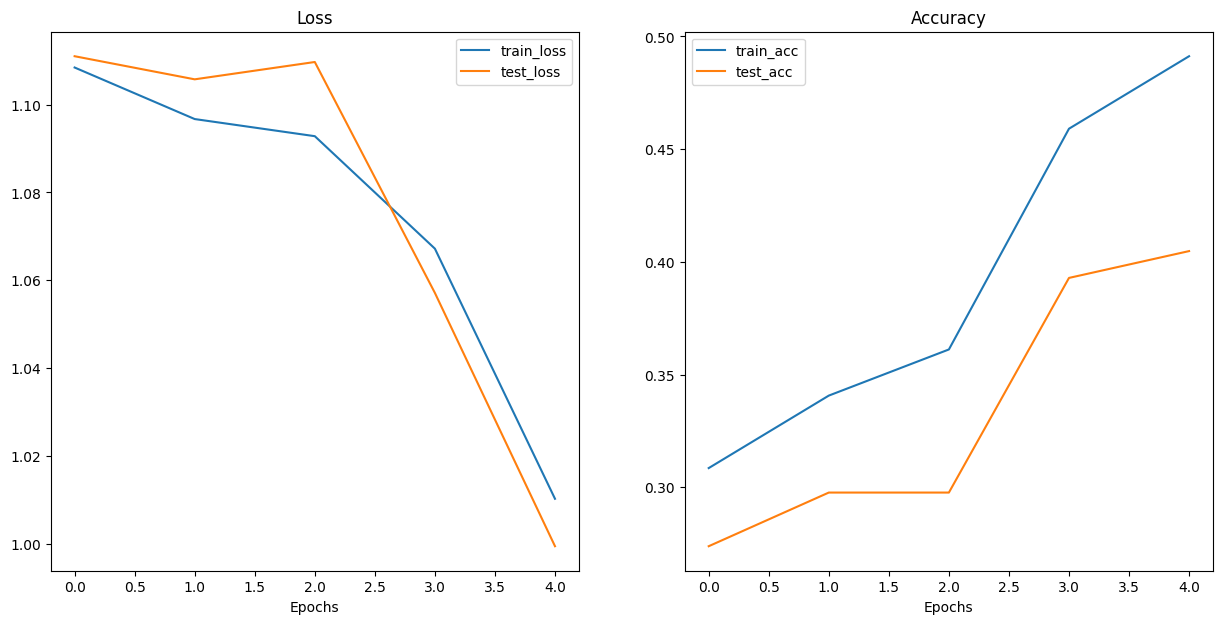

In [ ]:
plot_loss_curves(model_1_results)

## 11.1 Loading in a custom with PyTorch

We have to make sure our custom image is in the same format as the data our model was trained on.
* In tensor form with datatype (torch.float32)
* Of shape 64x64x3
* On the right device


In [ ]:
import torchvision

# Read custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
print(f"Custom image Tensor: {custom_image_uint8}")
print(f"Custom image shape: {custom_image_uint8.shape}")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image Tensor: tensor([[[242, 240, 238,  ..., 255, 255, 255],
         [249, 248, 246,  ..., 255, 255, 255],
         [254, 254, 252,  ..., 255, 255, 255],
         ...,
         [ 59,  63,  70,  ..., 112, 101,  89],
         [ 69,  61,  55,  ..., 113,  94,  79],
         [ 55,  70,  66,  ..., 118,  94,  77]],

        [[252, 252, 249,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [ 48,  52,  59,  ..., 123, 109,  97],
         [ 60,  52,  45,  ..., 125, 102,  87],
         [ 49,  61,  56,  ..., 130, 102,  85]],

        [[253, 252, 251,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [ 52,  56,  63,  ..., 143, 130, 118],
         [ 61,  53,  46,  ..., 147, 123, 108],
         [ 49,  62,  55,  ..., 152, 123, 106]]], dtype=torch.uint8)
Custom image shape: torch.Size([3, 360, 690])
Custom image dtype: 

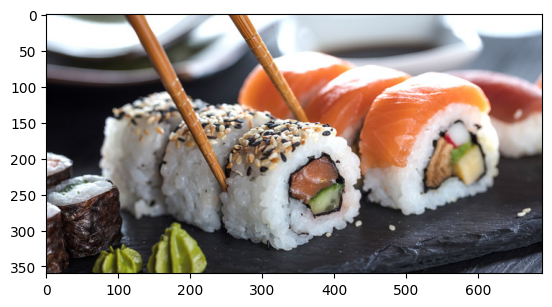

In [ ]:
plt.imshow(custom_image_uint8.permute(1,2,0));

### 11.2 Making a prediciton on a custom image with a trained PyTorch model

In [ ]:
# Load in the custom image an convert to torch.float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)/255 # Value between zero and one like our trained images

In [ ]:
# Create transform pipeline to resize image
from torchvision import transforms
custom_image_transform = transforms.Compose([
    transforms.Resize(size=(224,224))])

# Tansform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out the shape
print(f"Original shape: {custom_image.shape}")
print(f"Custom image shape: {custom_image_transformed.shape}")


Original shape: torch.Size([3, 360, 690])
Custom image shape: torch.Size([3, 64, 64])


In [ ]:
custom_image_transformed.shape

torch.Size([3, 64, 64])

In [ ]:
custom_image_uint8

tensor([[[242, 240, 238,  ..., 255, 255, 255],
         [249, 248, 246,  ..., 255, 255, 255],
         [254, 254, 252,  ..., 255, 255, 255],
         ...,
         [ 59,  63,  70,  ..., 112, 101,  89],
         [ 69,  61,  55,  ..., 113,  94,  79],
         [ 55,  70,  66,  ..., 118,  94,  77]],

        [[252, 252, 249,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [ 48,  52,  59,  ..., 123, 109,  97],
         [ 60,  52,  45,  ..., 125, 102,  87],
         [ 49,  61,  56,  ..., 130, 102,  85]],

        [[253, 252, 251,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [ 52,  56,  63,  ..., 143, 130, 118],
         [ 61,  53,  46,  ..., 147, 123, 108],
         [ 49,  62,  55,  ..., 152, 123, 106]]], dtype=torch.uint8)

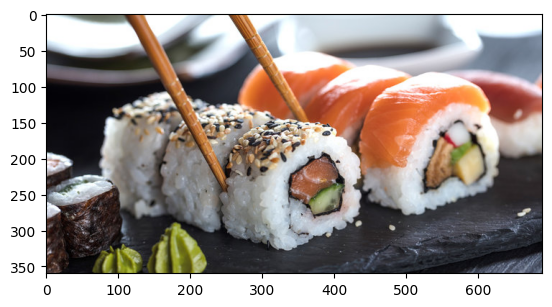

In [ ]:
plt.imshow(custom_image.permute(1,2,0));

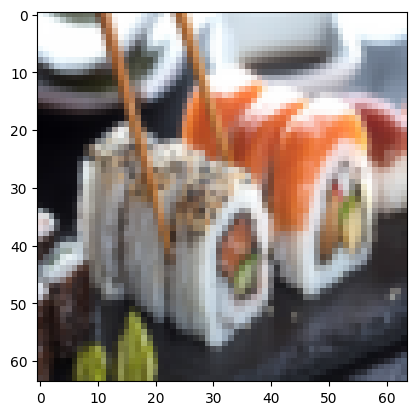

In [ ]:
plt.imshow(custom_image_transformed.permute(1,2,0));

In [ ]:
# Try to make a prediction on an image in uint8 format
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device)) # Batch size ((0) : on the first dimension) and same device
custom_image_pred

tensor([[ 0.3877, -0.8515,  0.2082]])

In [ ]:
class_names

['pizza', 'steak', 'sushi']

Note: to make a prediction on a custom image we had to:
* Load the image and turn it into tensor
* Make sure the image was the same datatype as the model (torch.float32)
* Make sure the image was the same shape as the data the model was trained on (3,64,64) with a batch size... (1,3,64,64)
* Make sure the image was on the same device as our model

In [ ]:
# Convert logits -> prediciton probabilities
custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
custom_image_pred_probs

tensor([[0.4705, 0.1363, 0.3932]])

In [ ]:
# Convert prediction probabilities -> predicition labels
custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
custom_image_pred_label

tensor([0])

In [ ]:
class_names[custom_image_pred_label]

'pizza'

### 11.3 Putting custom image prediction together: building a function

Ideal outcome:
A function where wa pass an image path to and have our model predict on that image and plot the image + prediction

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str]= None,
                        transform = None,
                        device=device):

  """ Makes a prediction on a target image with a trained model and plots the image and prediction."""
  # Load in the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # Divide the image pixel values by 255 to get them between [0, 1]
  target_image = target_image/255

  # Transform the target image if necessary
  if transform:
    target_image = transform(target_image)

  # Make sure the model is on the target device
  model.to(device)

  # Turn on eval/inference mode and make a prediction
  model.eval()
  with torch.inference_mode():
    # Add extra dimension to the image (this is the batch dimension, e.g. our model will predict on batches of 1x image)
    target_image = target_image.unsqueeze(dim=0)

    # Make a prediction on the image with an extra dimension
    target_image_pred = model(target_image.to(device)) # Make sure on the right device
    # Convert logits -> pred probs
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # Convert prediction probs -> pred labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # Plot the image alongside the prediction and prediciton probability
    plt.imshow(target_image.squeeze().permute(1,2,0)) # remove batch dimension
    if class_names:
      title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max():.3f}" # matplotlib works with the cpu
    else:
      title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max():.3f}"
    plt.title(title)
    plt.axis(False);

    print(f"prob: {target_image_pred_probs} and label: {class_names}")



prob: tensor([[0.4705, 0.1363, 0.3932]]) and label: ['pizza', 'steak', 'sushi']


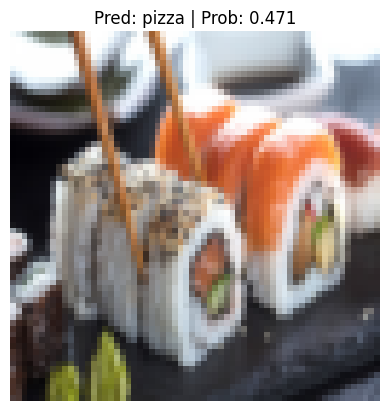

In [ ]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device = device)

## Exercices